# Quickstart

In [1]:
import datetime
import geospacelab.datahub as datahub
import geospacelab.visualization.mpl as gsl_mpl

## Swarm Data Access

### Initial settings

In [12]:
dt_fr = datetime.datetime(2016, 3, 15, 18, 18)
dt_to = datetime.datetime(2016, 3, 15, 18, 23)
sat_id = "A"

### Create a datahub

In [3]:

dh = datahub.DataHub(dt_fr=dt_fr, dt_to=dt_to, visual='on')

### Dock a Swarm dataset

Docking a dataset is the process of loading the dataset into the datahub. It is done by calling the `dock` method of the datahub object. The method takes the name patterns of the dataset as an argument and returns a dataset object.

The following code docks the Swarm MAG LR dataset for the specified time range (shown above) and satellite ID. A full list of the supported datasets and their name patterns can be found in the [Supported datasets](2_supported_datasets.ipynb) tutorial.

In [ ]:
ds = dh.dock(datasource_contents=['esa_eo', 'swarm', 'l1b', 'mag_lr'], sat_id=sat_id, add_APEX=True,)

Load IGRF coefficients ...


Searching the data product "MAG_LR" with the version "latest" on the server...
The file [PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_MDR_MAG_LR.cdf'), PosixPath('/data/afys-ionosphere/data/ESA/SWARM/Level1b/MAG_LR/0701/Sat_A/2016/SW_OPER_MAGA_LR_1B_20160315T000000_20160315T235959_0701_ASM_VFM_IC.cdf')] already exists: skip downloading.
/opt/anaconda3/envs/Swarm/lib/python3.12/site-packages/numpy/_core/numeric.py:476: RuntimeWarning: invalid value encountered in cast
  multiarray.copyto(res, fill_value, casting='unsafe')


#### List the variables included in the dataset

In [5]:
ds.list_all_variables()

Dataset: esa/earthonline | swarm | mag | mag_lr
Printing all of the variables ...
|No.                 |Variable name                 |Variable name (Source)        |Description                                                                                         |
|--------------------|------------------------------|------------------------------|----------------------------------------------------------------------------------------------------|
|1                   |SC_DATETIME                   |N/A                           |Time of observation                                                                                 |
|2                   |SYNC_STATUS                   |SyncStatus                    |                                                                                                    |
|3                   |SC_GEO_LAT                    |Latitude                      |Geographic Latitude                                                                       

#### Get a variable and data array

In [6]:
B_N = ds['B_N']

Above returns a GeospaceLAB Variable object. To get the data array, call

In [7]:

B_N_arr = B_N.value

Above returns a `numpy.ndarray` data array. 

## Swarm Data Visualization

The following example shows how to make the time series plots in GeospaceLAB with the Swarm MAG LR data. More examples can be found in [Examples](./example_Swarm_MAG.ipynb)

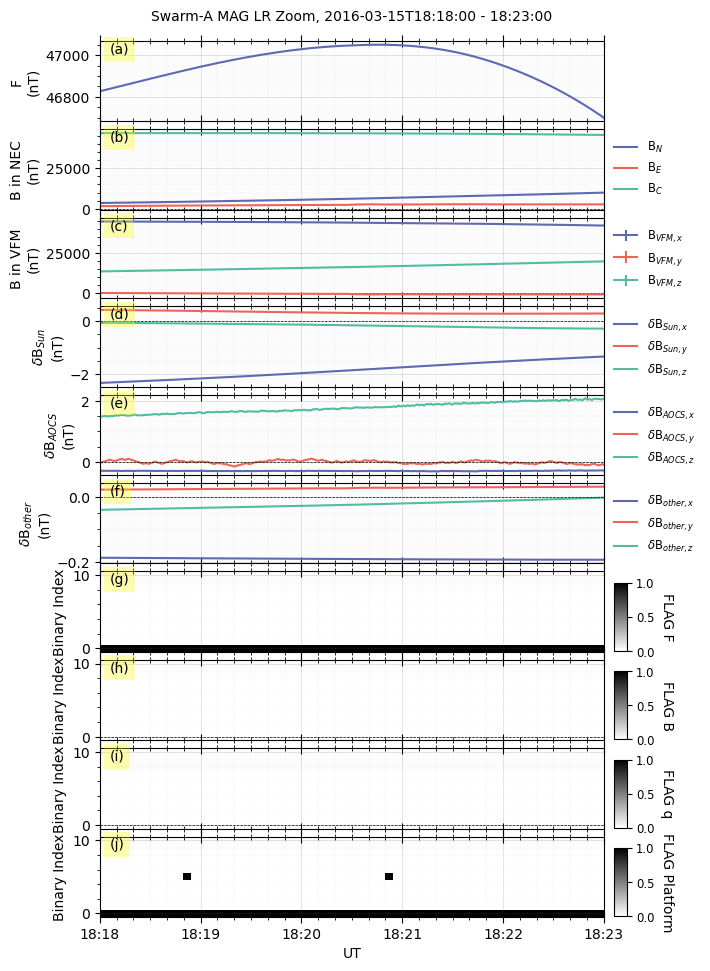

In [ ]:
# Create a figure
fig = gsl_mpl.create_figure(figsize=(8, 12))
# Add a time series dashboard to the figure
db = gsl_mpl.dashboards.TSDashboard(figure=fig, dt_fr=dt_fr, dt_to=dt_to)
# Set the panel layouts in the dashboard. 
# The layout is a list of lists, where each inner list represents a row of panels in the dashboard. 
# Each element in the inner list is a variable from the dataset that will be plotted in that panel.
# This allows for flexible arrangement of multiple plots in a single dashboard.
# To add or remove a panel, simply modify the inner lists accordingly. 
# For example, to remove the first panel, simply remove the first inner list: panel_layouts = [ [ds['B_N'], ds['B_E'], ds['B_C']], ... ]
panel_layouts = [
    [ds['F']],
    [ds['B_N'], ds['B_E'], ds['B_C']],
    [ds['B_VFM_x'], ds['B_VFM_y'], ds['B_VFM_z']],
    [ds['dB_Sun_VFM_x'], ds['dB_Sun_VFM_y'], ds['dB_Sun_VFM_z']],
    [ds['dB_AOCS_VFM_x'], ds['dB_AOCS_VFM_y'], ds['dB_AOCS_VFM_z']],
    [ds['dB_other_VFM_x'], ds['dB_other_VFM_y'], ds['dB_other_VFM_z']],
    [ds['FLAG_F_BIN_AUX']],
    [ds['FLAG_B_BIN_AUX']],
    [ds['FLAG_q_BIN_AUX']],
    [ds['FLAG_Platform_BIN_AUX']],
]
db.set_layout(panel_layouts)
# Plotting the data in the dashboard
db.draw()
# Add panel labels to the dashboard
db.add_panel_labels()
# Add a title to the dashboard
db.add_title(y=1.02,title='Swarm-{} MAG LR Zoom'.format(ds.sat_id), fontsize='medium', append_time=True)
# Show the figure/dashboard
db.show() 